# Modelo de árbol de decisión

In [40]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

EDA limpio 

In [41]:
# 1. Cargar los datos procesados
X_train_sel = pd.read_csv("clean_dataset_train.csv")
X_test_sel = pd.read_csv("clean_dataset_test.csv")

Visualizacion de Arboles de decision 

In [42]:
# Definimos los criterios disponibles para árboles de decisión
criteria = ['gini', 'entropy', 'log_loss']
criteria_results = {}

for crit in criteria:
    model = DecisionTreeClassifier(criterion=crit, random_state=42)
    model.fit(X_train_sel.drop(columns="Outcome"), X_train_sel["Outcome"])
    y_pred = model.predict(X_test_sel.drop(columns="Outcome"))

    acc = accuracy_score(X_test_sel["Outcome"], y_pred)
    cm = confusion_matrix(X_test_sel["Outcome"], y_pred)
    report = classification_report(X_test_sel["Outcome"], y_pred, output_dict=True)

    criteria_results[crit] = {
        'accuracy': acc,
        'confusion_matrix': cm,
        'report': report
    }


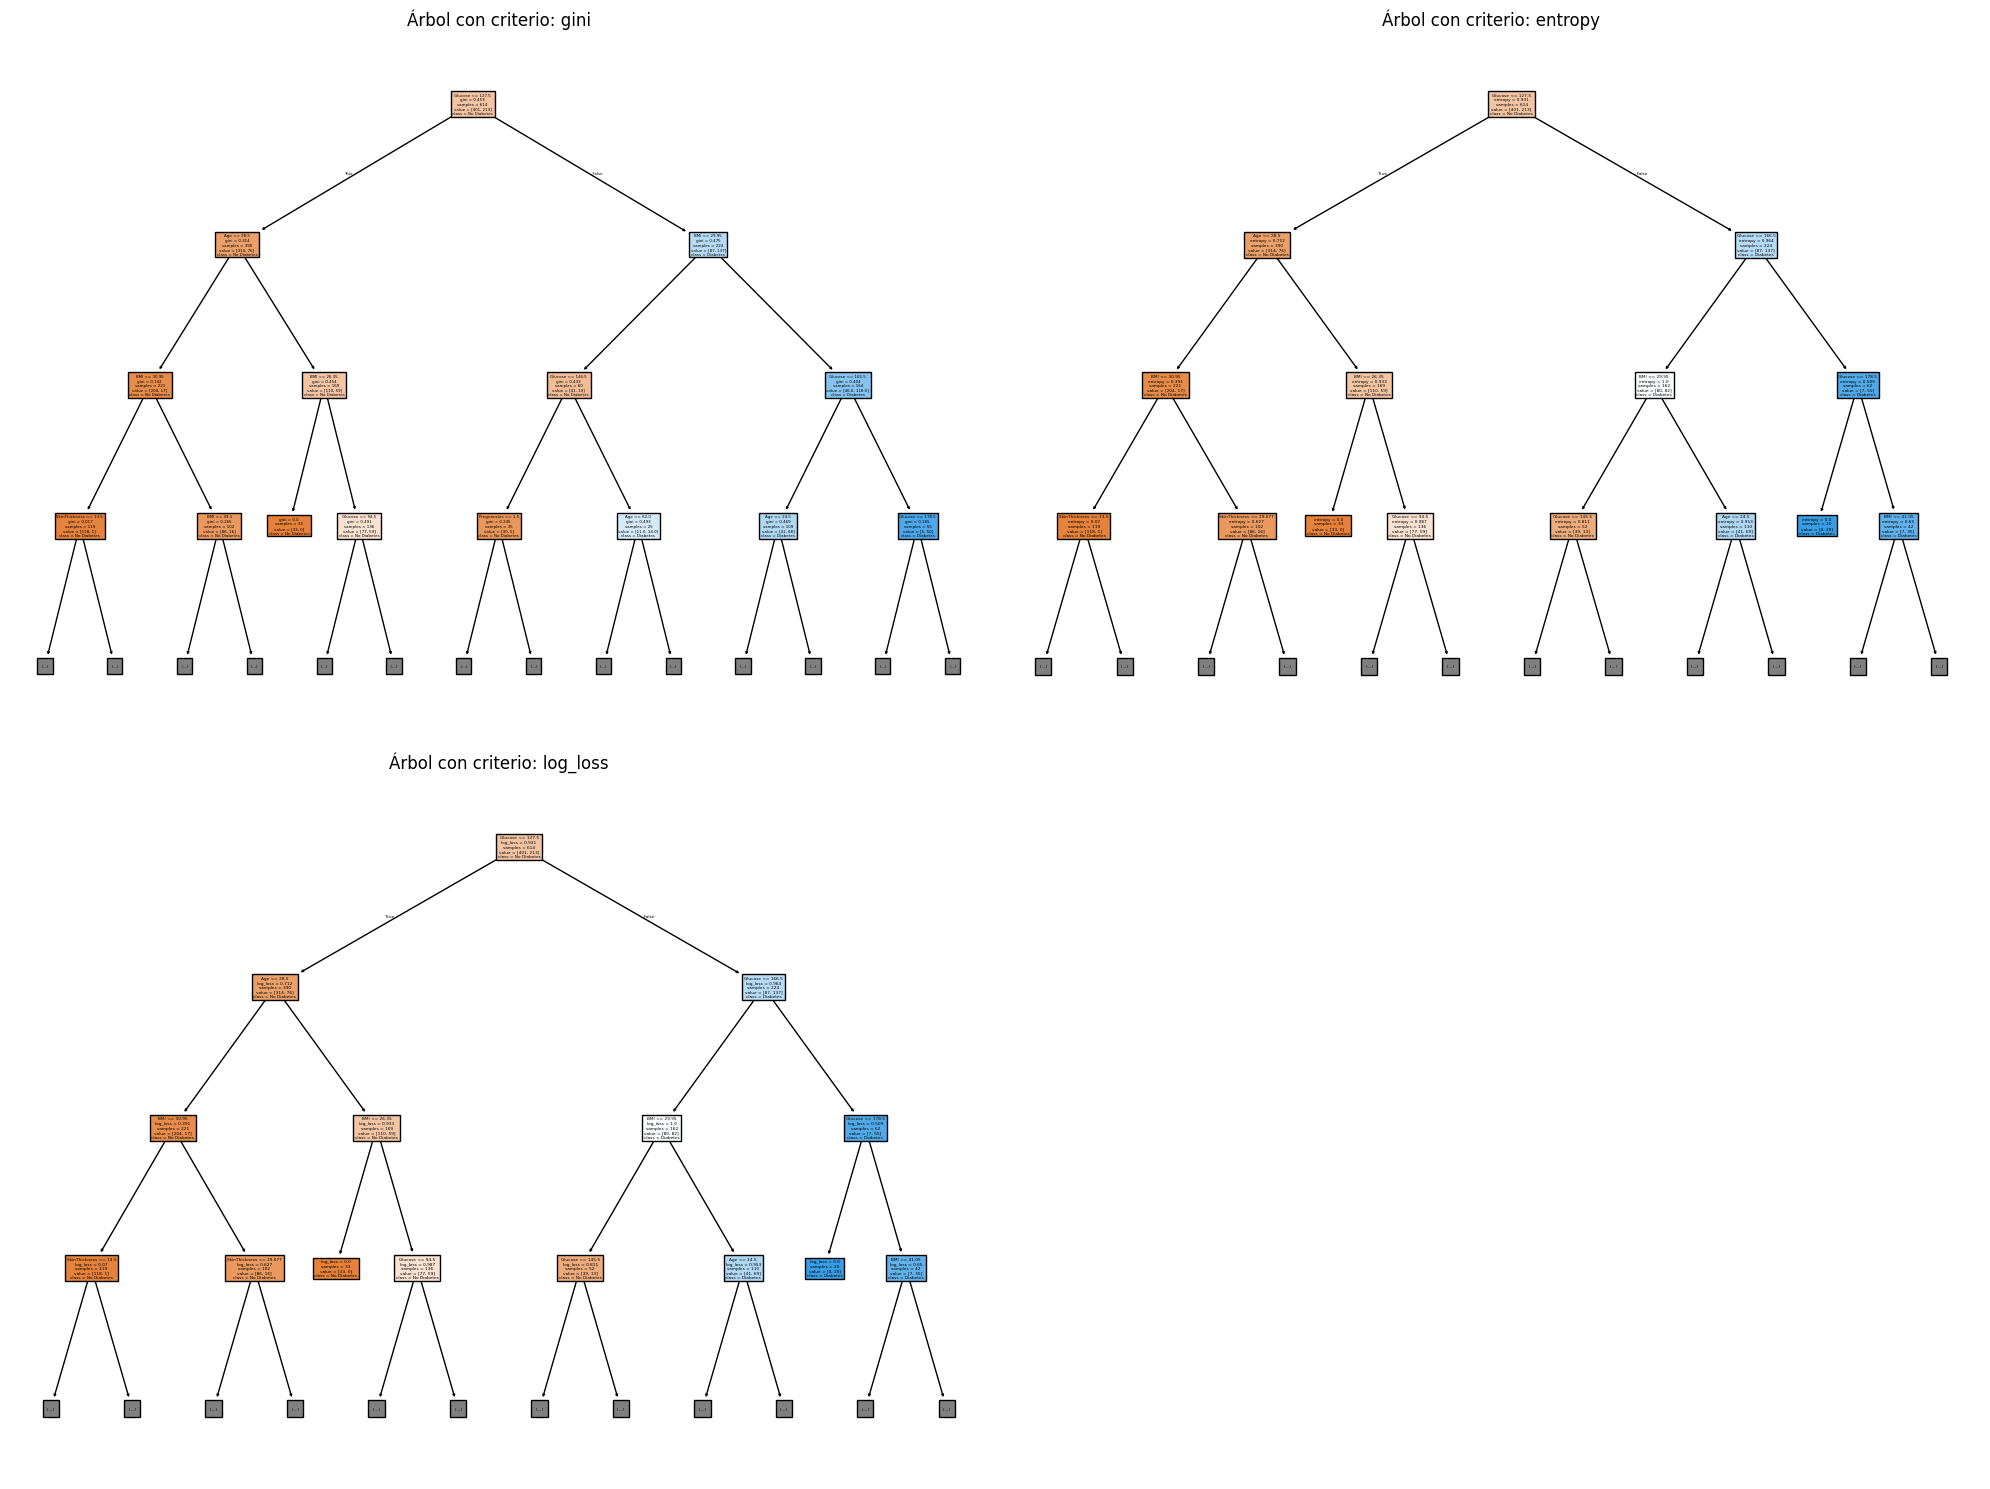

In [43]:
plt.figure(figsize=(20, 15))

# Entrenar y graficar cada árbol
for i, crit in enumerate(criteria):
    model = DecisionTreeClassifier(criterion=crit, random_state=42)
    model.fit(X_train_sel.drop(columns="Outcome"), X_train_sel["Outcome"])
    
    plt.subplot(2, 2, i+1)
    plot_tree(model, 
              feature_names=X_train_sel.drop(columns="Outcome").columns, 
              class_names=['No Diabetes', 'Diabetes'],
              filled=True, max_depth=3)
    plt.title(f"Árbol con criterio: {crit}")

plt.tight_layout()
plt.show()


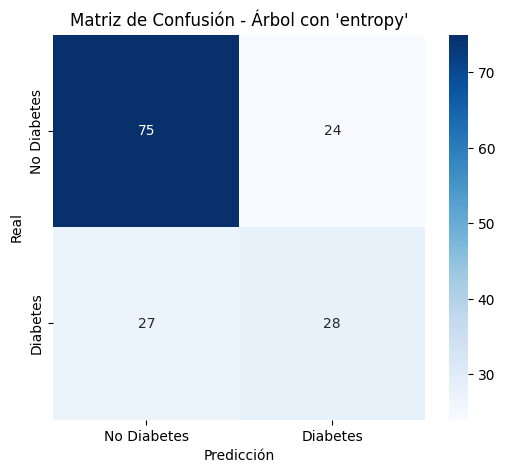

In [44]:
# ---------- MATRIZ DE CONFUSIÓN DEL MEJOR MODELO (entropy) ---------- #
best_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
best_model.fit(X_train_sel.drop(columns="Outcome"), X_train_sel["Outcome"])
y_pred = best_model.predict(X_test_sel.drop(columns="Outcome"))

cm = confusion_matrix(X_test_sel["Outcome"], y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Diabetes", "Diabetes"], 
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Matriz de Confusión - Árbol con 'entropy'")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

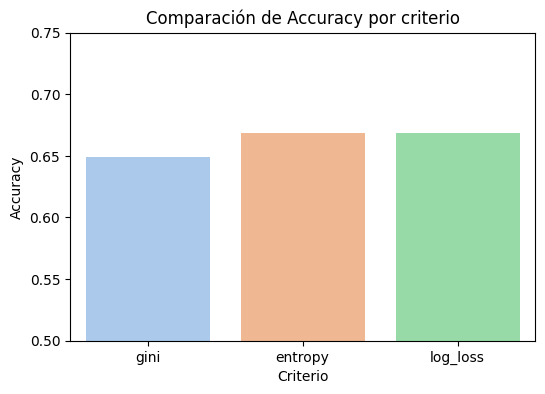

In [45]:
# ---------- COMPARACIÓN DE ACCURACY ENTRE CRITERIOS ---------- #

# Crear un DataFrame para usar hue correctamente
df_plot = pd.DataFrame({
    'Criterio': criteria,
    'Accuracy': acc_values
})

# Graficar usando hue
plt.figure(figsize=(6, 4))
sns.barplot(data=df_plot, x='Criterio', y='Accuracy', hue='Criterio', palette="pastel", legend=False)
plt.title("Comparación de Accuracy por criterio")
plt.ylabel("Accuracy")
plt.ylim(0.5, 0.75)
plt.show()


Conclusión del análisis con árbol de decisión

Se utilizó un modelo de árbol de decisión para predecir si una persona tiene diabetes, basándonos en diferentes datos médicos como el nivel de glucosa, la presión arterial o el índice de masa corporal.

Probamos tres formas diferentes de construir este modelo (llamadas criterios de pureza): gini, entropía y log loss. Aunque los nombres son técnicos, en términos simples son diferentes formas de ayudar al modelo a decidir cómo clasificar a una persona como con o sin diabetes.

Los resultados mostraron que:

El modelo con los métodos llamados entropía y log loss fue el más preciso, acertando aproximadamente: 

- entropy y log_loss alcanzan una mayor precisión (≈66.9%).

- gini es menos preciso en este problema (≈64.9%).

El modelo fue mejor identificando a las personas que no tienen diabetes que a las que sí la tienen.

Esto significa que, aunque el modelo es útil, puede pasar por alto algunos casos reales de diabetes, lo cual es importante si se quiere usar en un entorno médico.

Visualización:

El árbol de decisión permite ver de forma clara qué variables y umbrales utiliza el modelo para clasificar a los pacientes.
Las variables más relevantes suelen aparecer cerca de la raíz del árbol (por ejemplo, glucosa o BMI).

